Below is an implemtation of a Computational Graph System - MicroGrad. This was done by following the tutorials by Andrej Karpathy

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [72]:
def f(x):
    return 3*x**2 - 4*x + 5
x = np.arange(-5,5,0.25)
y = f(x)

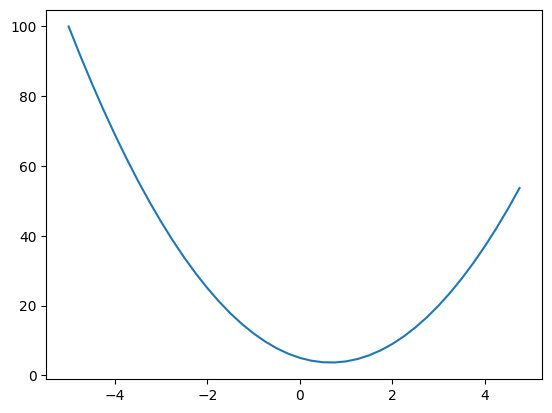

In [73]:
plt.plot(x,y)

In [74]:
h = 0.000001 
x = 2/3
(f(x+h) - f(x)) / h # derivate at x = 2/3

2.999378523327323e-06

In [75]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # wrt to c

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [76]:
class Value:
    def __init__(self, data, _children = (), _op = "", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda :None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value (data = {self.data})"
        
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other),'+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = np.tanh(x)
        out = Value(t, (self,), "tanh")
        
        def _backward():
            self.grad += (1 -t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo): # the backward pass
            node._backward() 

In [77]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [78]:
# Inputs
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'  # final output

In [79]:
L.backward()

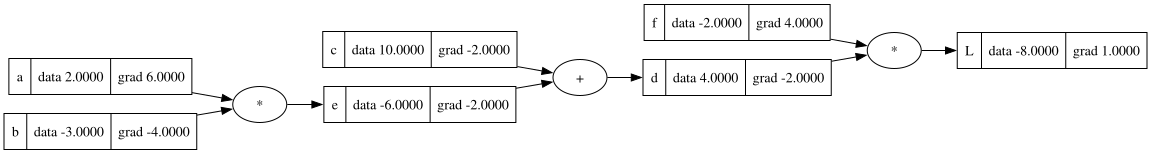

In [80]:
draw_dot(L)

In [81]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
    for child in v._prev:
        build_topo(child)
    topo.append(v)
build_topo(L)
topo

[Value (data = 10.0),
 Value (data = 2.0),
 Value (data = -3.0),
 Value (data = -6.0),
 Value (data = 4.0),
 Value (data = -2.0),
 Value (data = -8.0)]

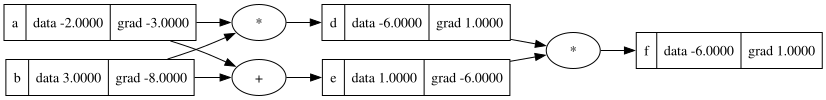

In [82]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

In [83]:
class Value:
    def __init__(self, data, _children = (), _op = "", label = ""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda :None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value (data = {self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else  Value(other)
        out = Value(self.data + other.data, (self, other),'+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else  Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "only supporting the int/float powers for now"
        out = Value(self.data**other,(self,),f"**{other}")
        def _backward():
            self.grad += other * self.data**(other-1) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = np.tanh(x)
        out = Value(t, (self,), "tanh")
        
        def _backward():
            self.grad += (1 -t**2) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other): # if self*other is not valid it checks for other * self
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return -1 * self
    
    def __sub__(self, other):
        return self + (-other)
    
    def __radd__(self, other): 
        return self + other

    def exp(self):
        x = self.data
        out = Value(np.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad 
        out._backward = _backward
        
        return out
    
    def backward(self): 
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo): # the backward pass
            node._backward() 

In [84]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [85]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

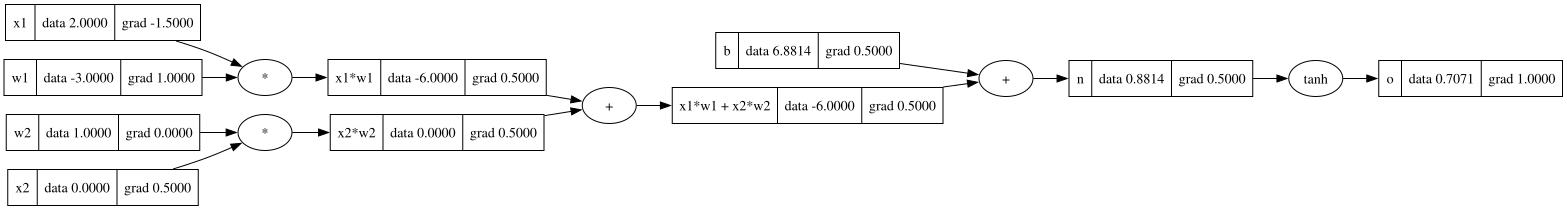

In [86]:
draw_dot(o)

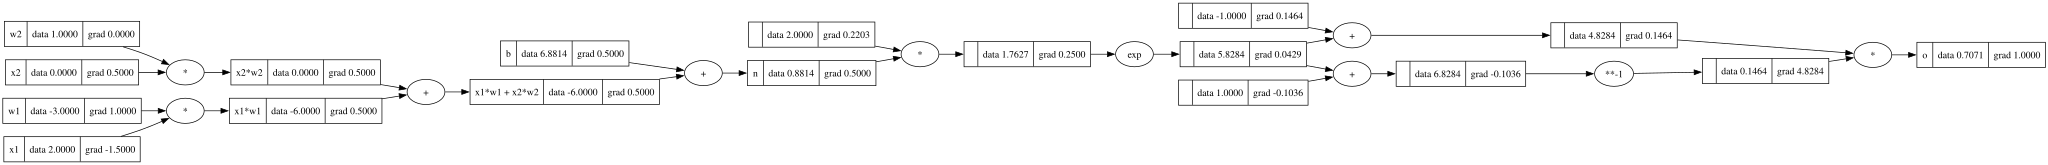

In [87]:
# same input output as above but using the exp function 
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [89]:
# implementing this backprop in torch
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True # using double to get the values as above as torch uses fp32 by default
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [137]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        # w * x + b
        act = sum([wi*xi for wi, xi in zip(self.w, x)], self.b) 
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]        

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] # uses the call function 
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]  

In [138]:
x = [2.0 , 3.0, 4.1]
n = Neuron(3)
n(x)

Value (data = -0.5951297039946698)

In [139]:
n = Layer(3, 3)
n(x)

[Value (data = 0.8546221491908637),
 Value (data = 0.9995147292871965),
 Value (data = 0.9363213483195723)]

In [143]:
x = [2,3,-1]
n = MLP(3, [4,4,1])
n(x)

Value (data = 0.9186461258832318)

In [ ]:
draw_dot(n(x))

In [146]:
# now lets get into the training of the above MLP

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [157]:
for k in range(20): 
    # forward pass
    y_pred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout,ygt in zip(y_pred,ys))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update 
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss)


0 Value (data = 0.006175557716263081)
1 Value (data = 0.006096638109109109)
2 Value (data = 0.006019565099386588)
3 Value (data = 0.0059442774210193595)
4 Value (data = 0.0058707164256929555)
5 Value (data = 0.005798825946148619)
6 Value (data = 0.005728552167907999)
7 Value (data = 0.005659843508830129)
8 Value (data = 0.005592650505949556)
9 Value (data = 0.005526925709089)
10 Value (data = 0.005462623580779165)
11 Value (data = 0.00539970040205496)
12 Value (data = 0.0053381141837307465)
13 Value (data = 0.00527782458278756)
14 Value (data = 0.005218792823532722)
15 Value (data = 0.005160981623218406)
16 Value (data = 0.005104355121828148)
17 Value (data = 0.005048878815762708)
18 Value (data = 0.004994519495175304)
19 Value (data = 0.004941245184725202)


In [158]:
y_pred

[Value (data = 0.9608661513432722),
 Value (data = -0.9556327994046686),
 Value (data = -0.9667135694800889),
 Value (data = 0.9817420666937825)]